# 1.Load Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# 2.check GPU

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

if device.type=="cuda":
    print("GPU:",torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


# 3.Dataset Paths

In [3]:
train_dir="/home/pratyush/deepfake_project/faces_train_test/train"
val_dir="/home/pratyush/deepfake_project/faces_train_test/val"

# 4.Image Transformation

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# 5.Load Dataset

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)

print("Classes:", train_dataset.classes)

Classes: ['fake', 'real']


# 6.DataLoaders

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 7.Load Model

In [8]:
model = timm.create_model(
    "xception",
    pretrained=True,
    num_classes=2
)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Train only classifier
model.fc = nn.Linear(model.fc.in_features,2)

model = model.to(device)

/mnt/d/deepfake/tf-gpu-env/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


# 8.Loss Function

In [9]:
weights = torch.tensor([1.3,1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

# 9.Optimizer

In [10]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [11]:
scaler = torch.cuda.amp.GradScaler()

# 10.Training Function

In [12]:
def train_epoch(loader):

    model.train()

    correct = 0
    total = 0

    for images,labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():

            outputs = model(images)
            loss = criterion(outputs,labels)

        optimizer.zero_grad()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _,pred = torch.max(outputs,1)

        correct += (pred==labels).sum().item()
        total += labels.size(0)

    return correct/total

# 11.Validation Function

In [13]:
def validate(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in tqdm(loader, desc="Validation"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _,pred = torch.max(outputs,1)

            correct += (pred==labels).sum().item()
            total += labels.size(0)

    acc = correct/total

    return acc

# 12.Train Loop

In [23]:
EPOCHS = 3

best_acc = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_acc = train_epoch(train_loader)

    val_acc = validate(val_loader)

    print(f"""
Train Acc : {train_acc:.4f}
Val Acc   : {val_acc:.4f}
""")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/mnt/d/deepfake/tf-gpu-env/complete_project/xception_deepfake_final.pth"
        )

        print("Model Saved")


Epoch 1/3


Validation: 100%|█████████████████████████████████████████████████████████████████████| 155/155 [11:24<00:00,  4.41s/it]



Train Acc : 0.9101
Val Acc   : 0.9210

Model Saved

Epoch 2/3


Validation: 100%|█████████████████████████████████████████████████████████████████████| 155/155 [11:18<00:00,  4.38s/it]



Train Acc : 0.9191
Val Acc   : 0.9247

Model Saved

Epoch 3/3


Validation: 100%|█████████████████████████████████████████████████████████████████████| 155/155 [11:11<00:00,  4.33s/it]



Train Acc : 0.9244
Val Acc   : 0.9312

Model Saved


# 13. Load trained model

In [14]:
import timm

model = timm.create_model("xception", pretrained=False, num_classes=2)

In [15]:
model.load_state_dict(torch.load(
    "/mnt/d/deepfake/tf-gpu-env/complete_project/models/xception_deepfake_final.pth",
    map_location=device
))

model = model.to(device)
model.eval()

Xception(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU(inplace=True)
  (block1): Block(
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (rep): Sequential(
      (0): SeparableConv2d(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): SeparableConv2d(
        (conv1): Conv

# 13.Metrics

In [17]:
from sklearn.metrics import classification_report, accuracy_score
import torch
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Fake","Real"]
    )
)

Accuracy: 0.9311528366646477

Classification Report:

              precision    recall  f1-score   support

        Fake       0.90      0.94      0.92      4260
        Real       0.96      0.92      0.94      5646

    accuracy                           0.93      9906
   macro avg       0.93      0.93      0.93      9906
weighted avg       0.93      0.93      0.93      9906



# 14.Confusion Matrix

Confusion Matrix:
[[4023  237]
 [ 445 5201]]


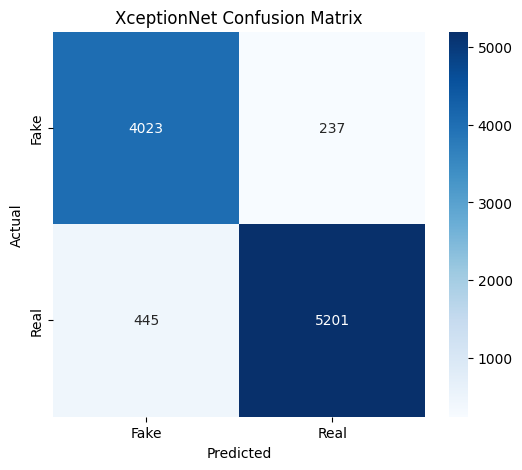

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XceptionNet Confusion Matrix")

plt.show()

# 15.prediction

In [20]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [22]:
image_path = "/mnt/d/deepfake/tf-gpu-env/complete_project/faces_train_test/val/fake/02_07__walking_and_outside_surprised__1VMZUH1W_266_1.jpg"

import cv2
import torch
from PIL import Image

img = cv2.imread(image_path)

if img is None:
    print("Image not found. Check path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = Image.fromarray(img)

    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        prob = torch.softmax(output, dim=1)

    fake_prob = prob[0][0].item()
    real_prob = prob[0][1].item()

    pred = "Fake" if fake_prob > real_prob else "Real"

    print("Prediction:", pred)
    print("Fake prob:", round(fake_prob,3))
    print("Real prob:", round(real_prob,3))

Prediction: Fake
Fake prob: 0.843
Real prob: 0.157


# 15.video Prediction

In [1]:
video_path = "/mnt/d/deepfake/deepfake-env/celeb-DF-v2/Celeb-synthesis/id1_id16_0009.mp4"

import cv2
import torch
import numpy as np
from PIL import Image

cap = cv2.VideoCapture(video_path)

fake_scores = []
real_scores = []

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

while True:

    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:

        face = frame[y:y+h, x:x+w]

        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

        # Convert to PIL Image (FIX)
        face = Image.fromarray(face)

        img = transform(face).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)
            prob = torch.softmax(output, dim=1)

        fake_prob = prob[0][0].item()
        real_prob = prob[0][1].item()

        fake_scores.append(fake_prob)
        real_scores.append(real_prob)

cap.release()

if len(fake_scores) == 0:
    print("No faces detected in video.")
else:

    fake_avg = np.mean(fake_scores)
    real_avg = np.mean(real_scores)

    prediction = "Fake" if fake_avg > real_avg else "Real"

    print("Video Prediction:", prediction)
    print("Fake Score:", round(fake_avg,3))
    print("Real Score:", round(real_avg,3))

NameError: name 'transform' is not defined